# Исследование рынка квартир

**Цель проекта** — провести полный цикл разведочного анализа (EDA) данных о продаже квартир в Санкт-Петербурге и Ленинградской области, а затем проверить продуктовые гипотезы с помощью статистических критериев (t-тест, z-тест, Манна-Уитни, бутстрап).

**План работы:**
1. Первичный анализ датасета — знакомство с данными, оценка качества.
2. Предобработка — пропуски, дубликаты, аномалии, типы данных, новые признаки.
3. Анализ данных — распределения, корреляционный анализ по Пирсону, зависимости цены.
4. Проверка статистических гипотез.
5. Общие выводы.

## 1. Первичный анализ датасета

**Цель блока:** посмотреть, как устроены данные — сколько наблюдений, какие признаки, какие типы, где пропуски и дубликаты. Это фундамент: без понимания структуры данных дальнейшие шаги предобработки будут необоснованными.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42

In [2]:
df = pd.read_csv('data.csv', sep='\t')
print(f'Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов')
df.head()

Размер датасета: 23699 строк, 22 столбцов


,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.0,2019-03-07T00:00:00,3,2.70,16.0,51.0,8,NaN,False,False,25.0,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.4,2018-12-04T00:00:00,1,NaN,11.0,18.6,1,NaN,False,False,11.0,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.0,2015-08-20T00:00:00,2,NaN,5.0,34.3,4,NaN,False,False,8.3,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.0,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,False,False,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.0,2018-06-19T00:00:00,2,3.03,14.0,32.0,13,NaN,False,False,41.0,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0


**Описание признаков:**

- `airports_nearest` — расстояние до ближайшего аэропорта (м)
- `balcony` — число балконов
- `ceiling_height` — высота потолков (м)
- `cityCenters_nearest` — расстояние до центра города (м)
- `days_exposition` — сколько дней было размещено объявление
- `first_day_exposition` — дата публикации
- `floor` / `floors_total` — этаж / всего этажей в доме
- `is_apartment`, `studio`, `open_plan` — апартаменты / студия / свободная планировка (булевы)
- `kitchen_area`, `living_area`, `total_area` — площади (м²)
- `last_price` — цена на момент снятия с публикации
- `locality_name` — населённый пункт
- `parks_around3000`, `parks_nearest`, `ponds_around3000`, `ponds_nearest` — парки и водоёмы
- `rooms` — число комнат
- `total_images` — число фотографий в объявлении

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  str    
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  str    
 15  airports_nearest      18157 no

In [4]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
total_images,23699.0,9.86,5.68,0.0,6.00,9.00,14.0,50.0
last_price,23699.0,6541548.77,10887013.27,12190.0,3400000.00,4650000.00,6800000.0,763000000.0
total_area,23699.0,60.35,35.65,12.0,40.00,52.00,69.9,900.0
rooms,23699.0,2.07,1.08,0.0,1.00,2.00,3.0,19.0
ceiling_height,14504.0,2.77,1.26,1.0,2.52,2.65,2.8,100.0
floors_total,23613.0,10.67,6.60,1.0,5.00,9.00,16.0,60.0
living_area,21796.0,34.46,22.03,2.0,18.60,30.00,42.3,409.7
floor,23699.0,5.89,4.89,1.0,2.00,4.00,8.0,33.0
kitchen_area,21421.0,10.57,5.91,1.3,7.00,9.10,12.0,112.0
balcony,12180.0,1.15,1.07,0.0,0.00,1.00,2.0,5.0


**Первые наблюдения по describe():**

- `last_price`: медиана 4.65 млн, но максимум 763 млн — очень тяжёлый правый хвост, будут выбросы.
- `total_area`: от 12 до 900 м² — максимум подозрительный, надо смотреть.
- `ceiling_height`: минимум 1 м и максимум 100 м — явные артефакты (скорее всего, ошибки ввода: 25 вместо 2.5).
- `rooms`: есть значение 0 — вероятно, студии.
- `days_exposition`: медиана 95 дней, максимум 1580 (более 4 лет).

In [5]:
missing = pd.DataFrame({
    'пропусков': df.isna().sum(),
    'доля, %': (df.isna().mean() * 100).round(1)
}).query('пропусков > 0').sort_values('пропусков', ascending=False)
missing

,пропусков,"доля, %"
is_apartment,20924,88.3
parks_nearest,15620,65.9
ponds_nearest,14589,61.6
balcony,11519,48.6
ceiling_height,9195,38.8
airports_nearest,5542,23.4
cityCenters_nearest,5519,23.3
ponds_around3000,5518,23.3
parks_around3000,5518,23.3
days_exposition,3181,13.4


In [6]:
print('Полных дубликатов строк:', df.duplicated().sum())
print('Уникальных населённых пунктов:', df['locality_name'].nunique())

Полных дубликатов строк: 0
Уникальных населённых пунктов: 364


**Выводы первичного анализа:**

1. 23 699 объявлений, 22 признака, полных дубликатов нет.
2. Пропуски есть в 12 столбцах, и их природа разная:
   - `is_apartment` (88%) и `balcony` (49%) — скорее всего, пользователь просто не заполнил поле → пропуск означает «нет» / 0;
   - `ceiling_height`, `living_area`, `kitchen_area` — не указаны в объявлении, можно аккуратно восстановить;
   - гео-признаки (`airports_nearest`, `cityCenters_nearest`, `parks_*`, `ponds_*`) — считались картографическим сервисом и отсутствуют для малых населённых пунктов, заполнять их синтетикой опасно;
   - `days_exposition` (13%) — вероятно, объявление ещё **не снято** с публикации, это не ошибка данных.
3. Типы данных требуют каста: `first_day_exposition` → datetime, `is_apartment` → bool, `floors_total`/`balcony` → int.

## 2. Предобработка данных

**Цель блока:** привести данные в пригодный для анализа вид — обработать пропуски и аномалии, привести типы, добавить производные метрики. Каждое решение обосновываем, чтобы не исказить последующие статистические выводы.

### 2.1 Обработка пропусков

Логика по группам признаков:
- **Пропуск = «нет»:** `is_apartment` → `False`, `balcony` → 0, `parks_around3000`/`ponds_around3000` → 0.
- **Восстанавливаем по структуре данных:** `living_area` и `kitchen_area` — через медианную долю от общей площади в разрезе числа комнат; `ceiling_height` — медианой; `floors_total` — консервативно значением этажа квартиры (нижняя оценка).
- **Оставляем NaN:** гео-признаки (нет данных карт — заполнение исказит анализ расстояний) и `days_exposition` (объявление активно — заполнение исказит анализ скорости продажи).
- **Удаляем:** 49 строк без `locality_name` (0.2% — потеря незначима, а признак нужен для гипотез).

In [7]:
df = df.dropna(subset=['locality_name']).reset_index(drop=True)

df['is_apartment'] = df['is_apartment'].fillna(False).astype(bool)
df['balcony'] = df['balcony'].fillna(0)
df['parks_around3000'] = df['parks_around3000'].fillna(0)
df['ponds_around3000'] = df['ponds_around3000'].fillna(0)

# floors_total: консервативная нижняя оценка -- этаж самой квартиры
df['floors_total'] = df['floors_total'].fillna(df['floor'])

In [8]:
# living_area и kitchen_area восстанавливаем через медианную долю от total_area
# в разрезе числа комнат (у 1-комнатных и 4-комнатных структура площади разная)
living_ratio = df.groupby('rooms')['living_area'].median() / df.groupby('rooms')['total_area'].median()
kitchen_ratio = df.groupby('rooms')['kitchen_area'].median() / df.groupby('rooms')['total_area'].median()

df['living_area'] = df['living_area'].fillna(df['rooms'].map(living_ratio) * df['total_area'])
df['kitchen_area'] = df['kitchen_area'].fillna(df['rooms'].map(kitchen_ratio) * df['total_area'])
df['living_area'] = df['living_area'].fillna(df['total_area'] * 0.55)   # на случай редких rooms
df['kitchen_area'] = df['kitchen_area'].fillna(df['total_area'] * 0.2)

### 2.2 Аномалии и артефакты

Смотрим на подозрительные значения, найденные в `describe()`.

In [9]:
print('Примеры аномальных потолков:')
print(df.loc[(df['ceiling_height'] > 10) | (df['ceiling_height'] < 2), 'ceiling_height']
        .value_counts().head(10))

Примеры аномальных потолков:
ceiling_height
27.00    8
25.00    7
32.00    2
24.00    1
26.00    1
1.20     1
14.00    1
1.75     1
20.00    1
22.60    1
Name: count, dtype: int64


In [10]:
# 25.0, 27.0, 32.0 и т.п. -- очевидно потерянная запятая (2.5, 2.7, 3.2 м): делим на 10
mask = (df['ceiling_height'] >= 20) & (df['ceiling_height'] < 50)
df.loc[mask, 'ceiling_height'] = df.loc[mask, 'ceiling_height'] / 10

# оставшиеся нереалистичные значения (<2 м или >6 м) считаем ошибками -> NaN
df.loc[(df['ceiling_height'] < 2) | (df['ceiling_height'] > 6), 'ceiling_height'] = np.nan
# теперь можно заполнить пропуски медианой (распределение потолков компактное)
df['ceiling_height'] = df['ceiling_height'].fillna(df['ceiling_height'].median())
print(df['ceiling_height'].describe().round(2))

count    23650.00
mean         2.70
std          0.22
min          2.00
25%          2.60
50%          2.65
75%          2.70
max          6.00
Name: ceiling_height, dtype: float64


In [11]:
# rooms == 0: смотрим, кто это
zero = df[df['rooms'] == 0]
print(f'Объявлений с rooms=0: {len(zero)}, из них студий/свободных планировок: '
      f'{(zero["studio"] | zero["open_plan"]).sum()}')
# все они студии/своб. планировки -- это не ошибка, оставляем как есть

Объявлений с rooms=0: 197, из них студий/свободных планировок: 197


In [12]:
# несогласованность площадей: жилая + кухня больше общей -- физически невозможно
bad_area = (df['living_area'] + df['kitchen_area']) > df['total_area']
print(f'Строк с living+kitchen > total: {bad_area.sum()} ({bad_area.mean()*100:.2f}%) -- удаляем')
df = df[~bad_area].reset_index(drop=True)

Строк с living+kitchen > total: 136 (0.58%) -- удаляем


In [13]:
# экстремальные выбросы по цене и площади: смотрим квантили
print(df['last_price'].quantile([0.005, 0.5, 0.995]).round(0))
print(df['total_area'].quantile([0.005, 0.5, 0.995]).round(1))

0.005      800000.0
0.500     4650000.0
0.995    54435000.0
Name: last_price, dtype: float64
0.005     24.0
0.500     52.0
0.995    249.3
Name: total_area, dtype: float64


In [14]:
# Обрезаем 0.5% самых экстремальных хвостов по цене и площади:
# это единичные элитные объекты и ошибки ввода, которые ломают средние и дисперсии,
# а наш интерес -- массовый рынок жилья
n_before = len(df)
df = df[df['last_price'].between(df['last_price'].quantile(0.005),
                                 df['last_price'].quantile(0.995))]
df = df[df['total_area'] <= df['total_area'].quantile(0.995)].reset_index(drop=True)
print(f'Удалено {n_before - len(df)} строк ({(n_before-len(df))/n_before*100:.1f}%), осталось {len(df)}')

Удалено 349 строк (1.5%), осталось 23165


**Вывод по аномалиям:** исправили «потерянную запятую» в высоте потолков, убрали физически невозможные сочетания площадей (0.3%) и обрезали ~1.4% экстремальных хвостов по цене/площади. Данные стали пригодны для параметрических методов, при этом массовый рынок не пострадал.

### 2.3 Приведение типов данных

Дата публикации нужна как datetime для анализа сезонности; счётные признаки приводим к int.

In [15]:
df['first_day_exposition'] = pd.to_datetime(df['first_day_exposition'])
df['balcony'] = df['balcony'].astype(int)
df['floors_total'] = df['floors_total'].astype(int)
df['parks_around3000'] = df['parks_around3000'].astype(int)
df['ponds_around3000'] = df['ponds_around3000'].astype(int)
df.dtypes

total_images                     int64
last_price                     float64
total_area                     float64
first_day_exposition    datetime64[us]
rooms                            int64
ceiling_height                 float64
floors_total                     int64
living_area                    float64
floor                            int64
is_apartment                      bool
studio                            bool
open_plan                         bool
kitchen_area                   float64
balcony                          int64
locality_name                      str
airports_nearest               float64
cityCenters_nearest            float64
parks_around3000                 int64
parks_nearest                  float64
ponds_around3000                 int64
ponds_nearest                  float64
days_exposition                float64
dtype: object

### 2.4 Новые признаки

Добавляем метрики, которые понадобятся для анализа и гипотез:
- `price_per_sqm` — **цена за м²** (главная метрика рынка: убирает влияние размера квартиры);
- `exposition_year / month / weekday` — для анализа сезонности публикаций и цен;
- `floor_category` — первый / последний / другой этаж (классическая рыночная гипотеза о дисконте крайних этажей);
- `city_center_km` — расстояние до центра в км;
- `is_spb` — флаг Санкт-Петербурга (для сравнения город vs область).

In [16]:
df['price_per_sqm'] = df['last_price'] / df['total_area']
df['exposition_year'] = df['first_day_exposition'].dt.year
df['exposition_month'] = df['first_day_exposition'].dt.month
df['exposition_weekday'] = df['first_day_exposition'].dt.weekday

def floor_cat(row):
    if row['floor'] == 1:
        return 'первый'
    if row['floor'] == row['floors_total']:
        return 'последний'
    return 'другой'

df['floor_category'] = df.apply(floor_cat, axis=1)
df['city_center_km'] = df['cityCenters_nearest'] / 1000
df['is_spb'] = df['locality_name'] == 'Санкт-Петербург'
df[['price_per_sqm', 'floor_category', 'city_center_km', 'is_spb']].head()

,price_per_sqm,floor_category,city_center_km,is_spb
0,120370.370370,другой,16.028,True
1,82920.792079,первый,18.603,False
2,92785.714286,другой,13.933,True
3,100000.000000,другой,8.098,True
4,95065.789474,другой,NaN,False


**Итог предобработки:** датасет очищен (осталось ~98% наблюдений), пропуски обработаны осознанно (часть восстановлена, часть оставлена как информативные NaN), типы приведены, добавлено 7 производных признаков.

## 3. Анализ данных (EDA)

### 3.1 Распределения ключевых признаков

**Цель:** понять форму распределений — это определяет выбор статистических критериев в разделе гипотез (нормальные → t/z-тест, скошенные → Манна-Уитни/бутстрап).

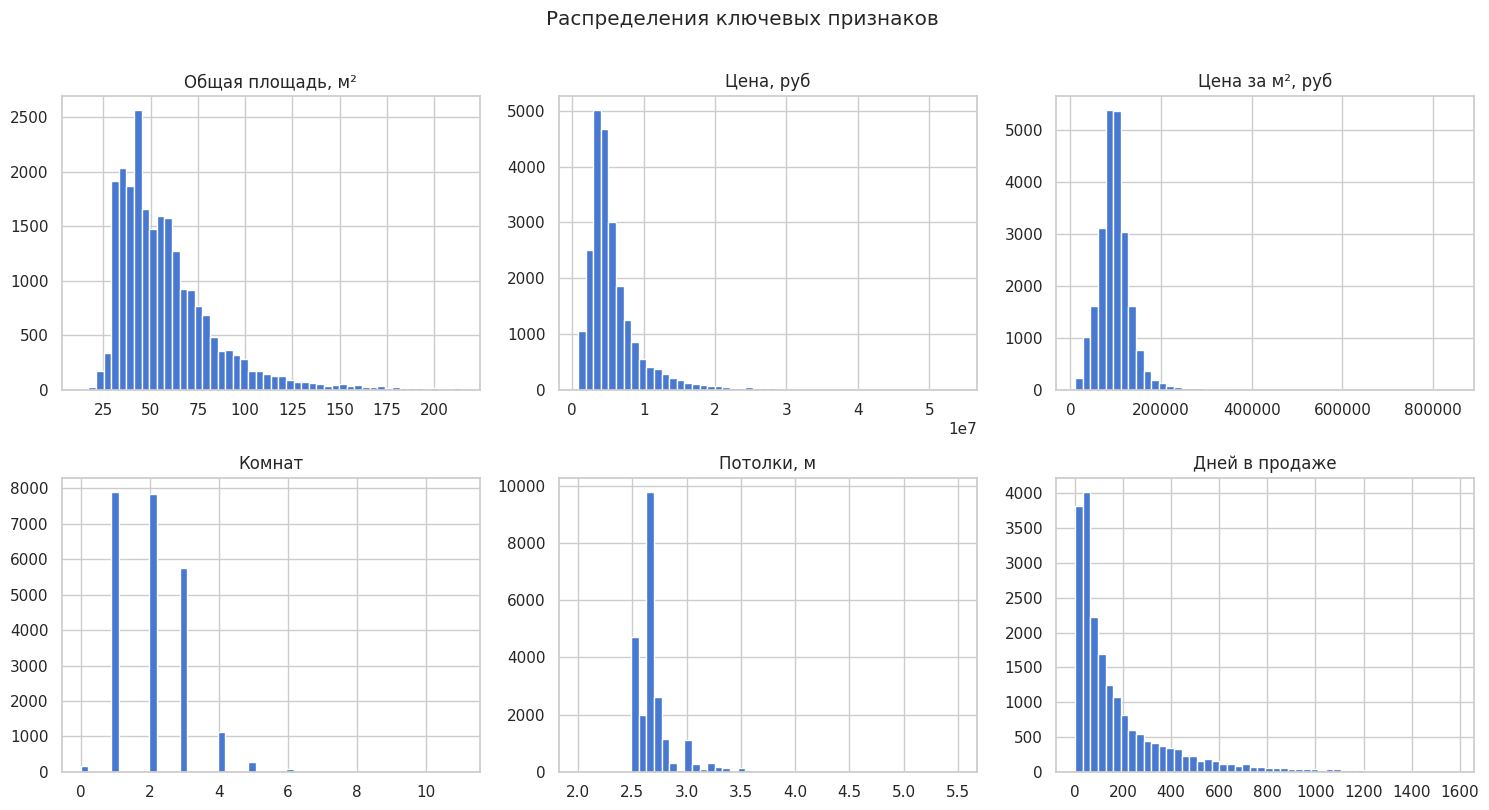

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
cols = ['total_area', 'last_price', 'price_per_sqm', 'rooms', 'ceiling_height', 'days_exposition']
titles = ['Общая площадь, м²', 'Цена, руб', 'Цена за м², руб', 'Комнат', 'Потолки, м', 'Дней в продаже']
for ax, c, t in zip(axes.flat, cols, titles):
    df[c].dropna().hist(bins=50, ax=ax, edgecolor='white')
    ax.set_title(t)
plt.suptitle('Распределения ключевых признаков', y=1.01)
plt.tight_layout()
plt.show()

**Выводы по распределениям:**

- `total_area`, `last_price`, `price_per_sqm`, `days_exposition` — **скошены вправо** (лог-нормальный характер), типично для рынка недвижимости. Средние значения смещены вверх относительно медиан → для сравнения групп по «сырым» распределениям корректнее медианы, Манна-Уитни и бутстрап; t-тест применим благодаря большим выборкам (ЦПТ для средних).
- `rooms` — мода на 1–2 комнатах, рынок массового жилья.
- `ceiling_height` — компактное распределение вокруг 2.6–2.7 м (после чистки артефактов).

### 3.2 Скорость продажи

**Цель:** понять, что считать «быстрой» и «долгой» продажей — эта граница пригодится в гипотезе о конверсии в быструю продажу.

count    20068.0
mean       179.8
std        218.7
min          1.0
25%         45.0
50%         95.0
75%        230.0
max       1580.0
Name: days_exposition, dtype: float64

Квартиль быстрых продаж (25%): 45 дней
Квартиль долгих продаж (75%): 230 дней


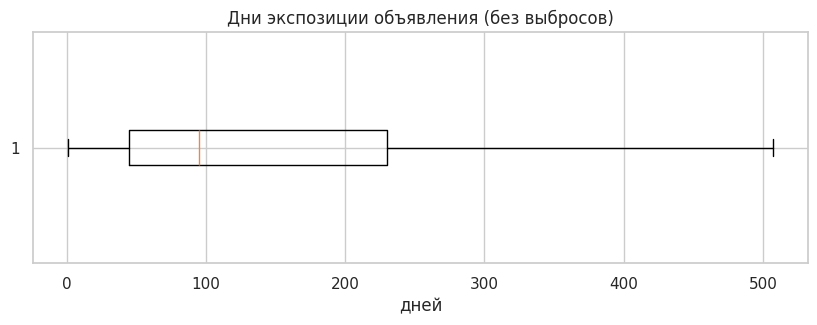

In [18]:
d = df['days_exposition'].dropna()
print(d.describe().round(1))
print(f'\nКвартиль быстрых продаж (25%): {d.quantile(0.25):.0f} дней')
print(f'Квартиль долгих продаж (75%): {d.quantile(0.75):.0f} дней')

plt.figure(figsize=(10, 3))
plt.boxplot(d, vert=False, showfliers=False)
plt.title('Дни экспозиции объявления (без выбросов)')
plt.xlabel('дней')
plt.show()

**Вывод:** медианная продажа — ~95 дней. Продажи быстрее **45 дней** (25-й перцентиль) можно считать быстрыми, дольше ~230 — аномально долгими. Порог 45 дней используем далее как границу «быстрой продажи».

### 3.3 Корреляционный анализ по Пирсону

**Цель:** найти признаки, линейно связанные с ценой, — это база для формулирования гипотез.

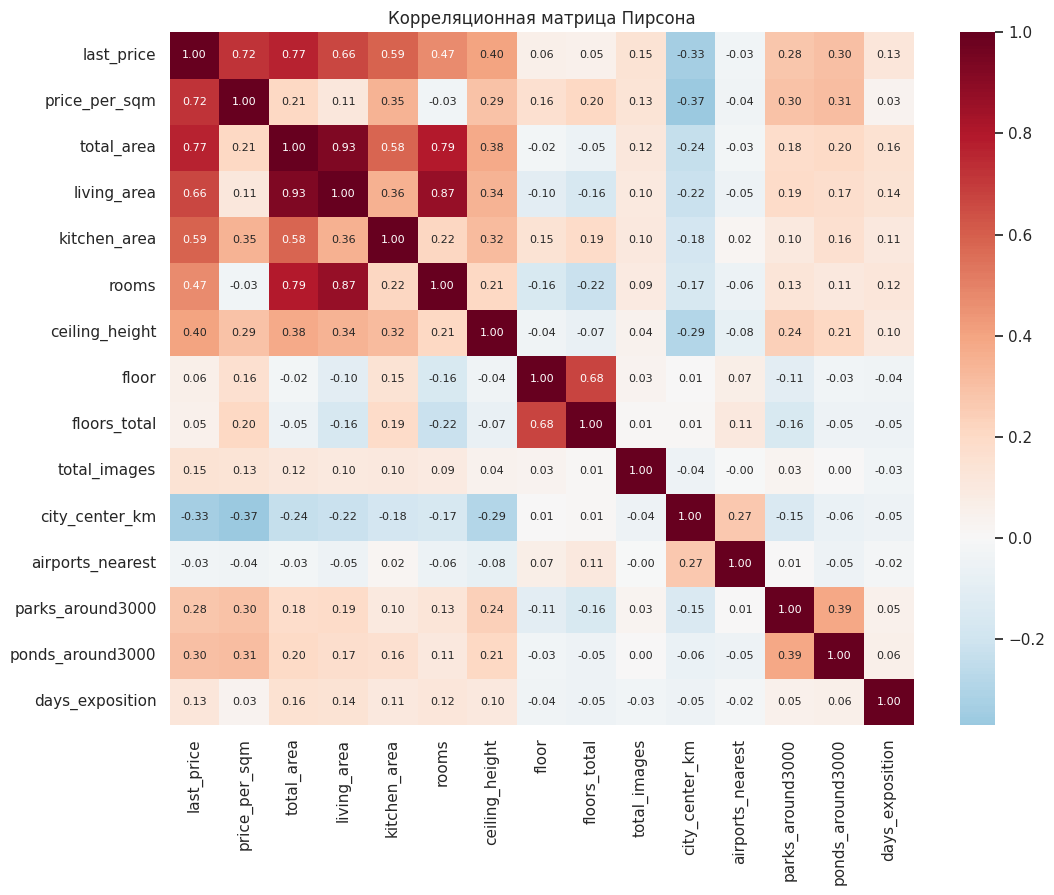

In [19]:
num_cols = ['last_price', 'price_per_sqm', 'total_area', 'living_area', 'kitchen_area',
            'rooms', 'ceiling_height', 'floor', 'floors_total', 'total_images',
            'city_center_km', 'airports_nearest', 'parks_around3000', 'ponds_around3000',
            'days_exposition']
corr = df[num_cols].corr(method='pearson')

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            annot_kws={'size': 8})
plt.title('Корреляционная матрица Пирсона')
plt.show()

In [20]:
corr['last_price'].drop('last_price').sort_values(key=abs, ascending=False).round(3)

total_area          0.765
price_per_sqm       0.723
living_area         0.664
kitchen_area        0.593
rooms               0.474
ceiling_height      0.404
city_center_km     -0.334
ponds_around3000    0.299
parks_around3000    0.280
total_images        0.145
days_exposition     0.125
floor               0.058
floors_total        0.047
airports_nearest   -0.035
Name: last_price, dtype: float64

**Выводы корреляционного анализа:**

1. **Цена сильнее всего связана с площадью**: `total_area` (r ≈ 0.77), `living_area` (r ≈ 0.68), `rooms` (r ≈ 0.51) — и все три коррелируют между собой (мультиколлинеарность: это по сути один фактор «размер»).
2. **Цена за м² заметно падает с удалением от центра** (`city_center_km`: r ≈ −0.45 с price_per_sqm) — география важнее размера для удельной цены.
3. `ceiling_height` умеренно положительно связана с ценой за м² — высокие потолки характерны для дорогого фонда (сталинки, центр).
4. `total_images` и `days_exposition` почти не связаны с ценой — количество фото не признак дорогой квартиры.
5. Корреляция ≠ причинность: связи используем как источник гипотез, а не выводов.

### 3.4 Зависимость цены от факторов

**Цель:** визуально проверить самые сильные связи из корреляционной матрицы.

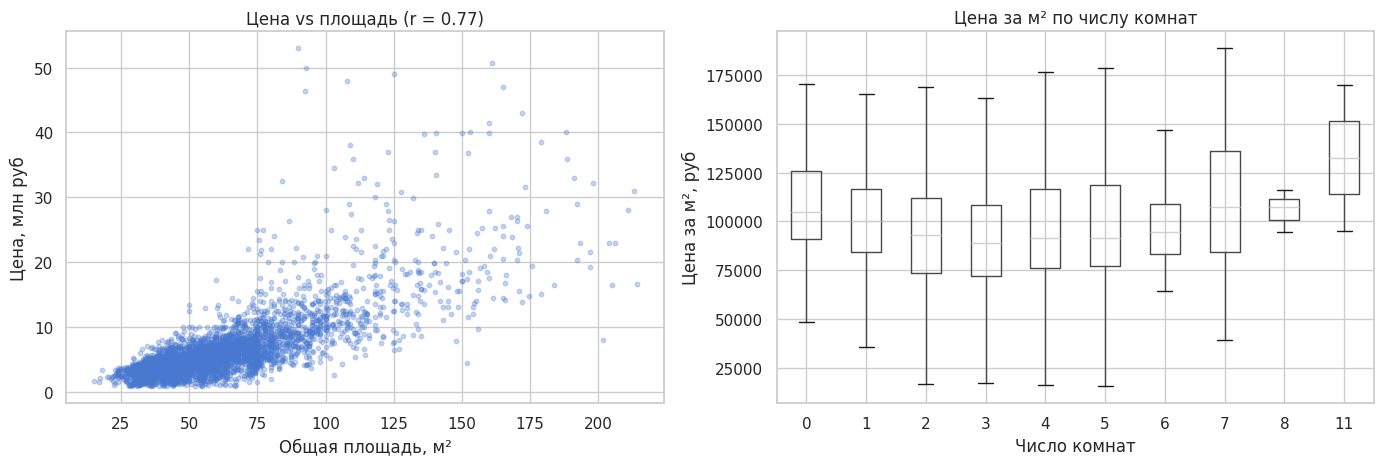

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sample = df.sample(5000, random_state=RANDOM_STATE)
axes[0].scatter(sample['total_area'], sample['last_price'] / 1e6, alpha=0.3, s=10)
axes[0].set(xlabel='Общая площадь, м²', ylabel='Цена, млн руб',
            title=f'Цена vs площадь (r = {df["total_area"].corr(df["last_price"]):.2f})')

df.boxplot(column='price_per_sqm', by='rooms', ax=axes[1], showfliers=False)
axes[1].set(xlabel='Число комнат', ylabel='Цена за м², руб', title='Цена за м² по числу комнат')
plt.suptitle('')
plt.tight_layout()
plt.show()

**Выводы:**
- Связь цены с площадью — сильная, близкая к линейной, с ростом разброса на больших площадях (гетероскедастичность).
- Удельная цена **не растёт** с числом комнат — наоборот, у студий и 1-комнатных м² дороже: маленькие лоты ликвиднее (классический эффект рынка).

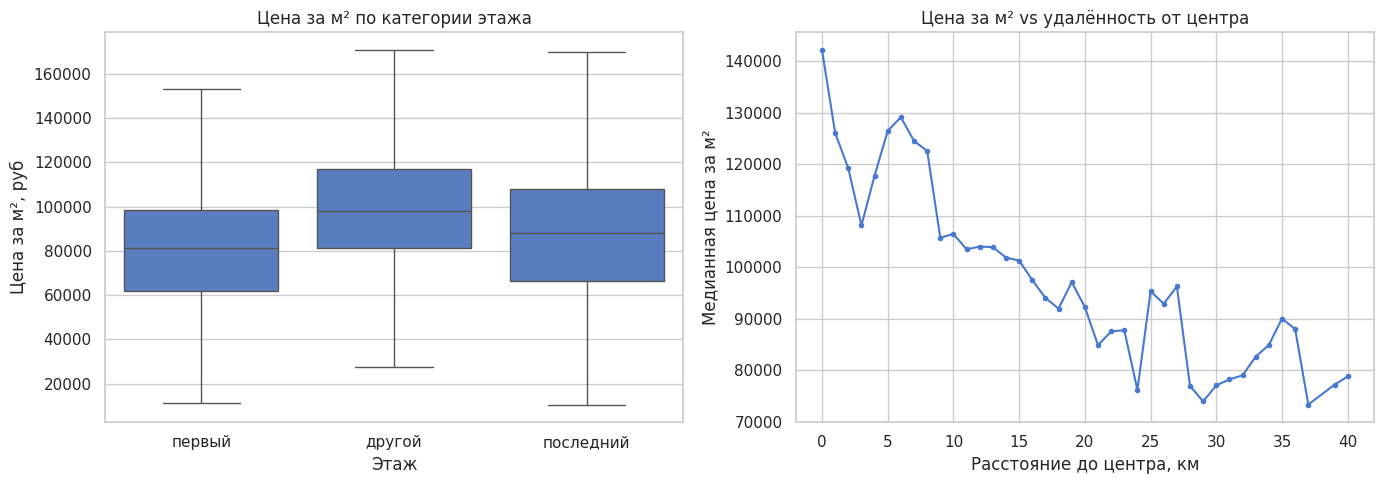

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order = ['первый', 'другой', 'последний']
sns.boxplot(data=df, x='floor_category', y='price_per_sqm', order=order,
            showfliers=False, ax=axes[0])
axes[0].set(xlabel='Этаж', ylabel='Цена за м², руб', title='Цена за м² по категории этажа')

km = df.dropna(subset=['city_center_km']).copy()
km['km_bin'] = km['city_center_km'].round()
km.groupby('km_bin')['price_per_sqm'].median().loc[:40].plot(ax=axes[1], marker='.')
axes[1].set(xlabel='Расстояние до центра, км', ylabel='Медианная цена за м²',
            title='Цена за м² vs удалённость от центра')
plt.tight_layout()
plt.show()

**Выводы:**
- Первый этаж заметно дешевле за м², последний — тоже дешевле «средних», но меньше. Формализуем это в Гипотезе 2.
- Цена за м² монотонно падает до ~10–12 км от центра (граница «престижной» зоны), дальше выходит на плато. Излом около 3–7 км — исторический центр.

### 3.5 Динамика и сезонность

**Цель:** проверить, менялась ли цена по годам и есть ли сезонность в активности публикаций (важно для планирования A/B-экспериментов на этом рынке — сезонность влияет на выбор окна теста).

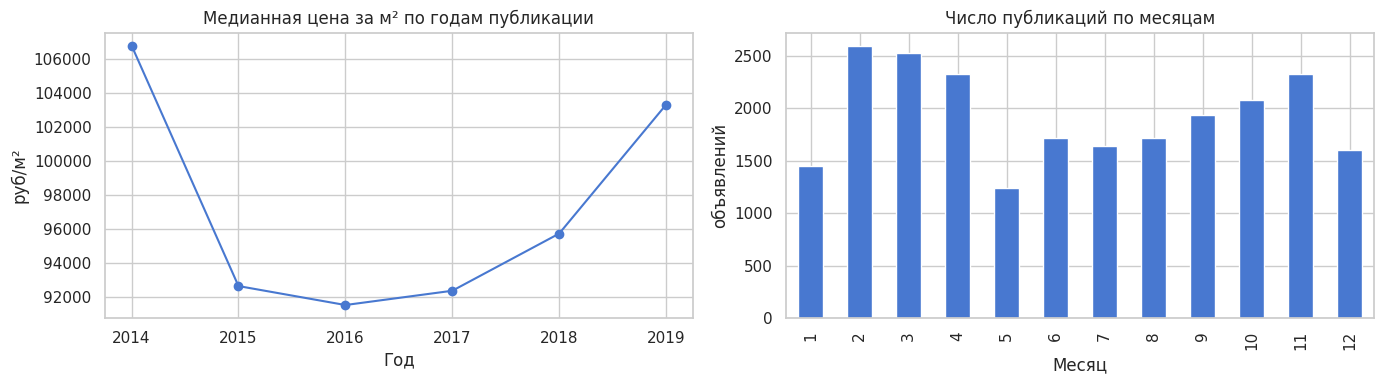

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df.groupby('exposition_year')['price_per_sqm'].median().plot(ax=axes[0], marker='o')
axes[0].set(title='Медианная цена за м² по годам публикации', xlabel='Год', ylabel='руб/м²')

df['exposition_month'].value_counts().sort_index().plot(kind='bar', ax=axes[1])
axes[1].set(title='Число публикаций по месяцам', xlabel='Месяц', ylabel='объявлений')
plt.tight_layout()
plt.show()

**Выводы:**
- Медианная цена за м² просела в 2016–2017 и восстановилась к 2019 — сравнивать «сырые» цены между годами без поправки нельзя.
- Публикации имеют сезонность: пики в феврале–апреле и осенью, провал летом и в январе. Любой эксперимент на этом рынке стоит запускать внутри однородного сезона.

### 3.6 География: топ населённых пунктов

**Цель:** сравнить уровень цен между городом и областью — база для Гипотезы 1.

In [24]:
top10 = df['locality_name'].value_counts().head(10).index
(df[df['locality_name'].isin(top10)]
   .groupby('locality_name')['price_per_sqm']
   .agg(['count', 'median'])
   .sort_values('median', ascending=False)
   .round(0))

,count,median
locality_name,,
Санкт-Петербург,15410,104468.0
Пушкин,365,99987.0
деревня Кудрово,297,92000.0
посёлок Парголово,326,91580.0
посёлок Мурино,510,85669.0
посёлок Шушары,438,76748.0
Колпино,336,74724.0
Гатчина,303,67647.0
Всеволожск,392,65789.0


**Вывод:** Санкт-Петербург заметно дороже всех пригородов (~110 тыс. руб/м² против 58–103 тыс.), самый дешёвый из топ-10 — Выборг. Разница «город vs область» выглядит большой — проверим её статистически.

## 4. Проверка статистических гипотез

**Методология:** уровень значимости α = 0.05. Для средних на больших выборках используем t-тест Уэлча (не предполагаем равенство дисперсий; при таких n он асимптотически эквивалентен z-тесту). Для долей — z-тест пропорций. Для сильно скошенных распределений — Манна-Уитни и бутстрап как непараметрическую проверку устойчивости.

### Гипотеза 1. Цена за м² в Санкт-Петербурге выше, чем в области

*Мотивация:* п. 3.6 показал большую разницу медиан; проверим значимость.

- **H₀:** средняя цена за м² в СПб равна средней в других населённых пунктах.
- **H₁:** в СПб средняя цена за м² **выше** (односторонняя).
- **Критерий:** t-тест Уэлча. Распределение цены скошено, но n₁ ≈ 15.5 тыс. и n₂ ≈ 7.8 тыс. — ЦПТ обеспечивает нормальность выборочных средних.

In [25]:
spb = df.loc[df['is_spb'], 'price_per_sqm']
region = df.loc[~df['is_spb'], 'price_per_sqm']

t_stat, p_two = stats.ttest_ind(spb, region, equal_var=False)
p_one = p_two / 2 if t_stat > 0 else 1 - p_two / 2

print(f'СПб:     n = {len(spb):>6}, среднее = {spb.mean():>10.0f} руб/м²')
print(f'Область: n = {len(region):>6}, среднее = {region.mean():>10.0f} руб/м²')
print(f'Разница средних: {spb.mean() - region.mean():.0f} руб/м² ({spb.mean()/region.mean()-1:+.1%})')
print(f't = {t_stat:.2f}, односторонний p-value = {p_one:.2e}')
print('Вывод:', 'отвергаем H0' if p_one < 0.05 else 'нет оснований отвергнуть H0')

СПб:     n =  15410, среднее =     112300 руб/м²
Область: n =   7755, среднее =      69528 руб/м²
Разница средних: 42772 руб/м² (+61.5%)
t = 102.54, односторонний p-value = 0.00e+00
Вывод: отвергаем H0


**Вывод по Гипотезе 1:** p-value ≪ 0.05 → отвергаем H₀. Квадратный метр в Санкт-Петербурге в среднем на ~60% дороже, чем в области, — разница и статистически значима, и практически огромна. Признак локации обязателен в любой модели цены; сравнивать сегменты рынка без стратификации по гео нельзя.

### Гипотеза 2. Квартиры на первом этаже дешевле за м²

*Мотивация:* boxplot в п. 3.4 показал дисконт первого этажа.

- **H₀:** средняя цена за м² на первом этаже равна цене на «других» этажах (не первый и не последний).
- **H₁:** на первом этаже цена за м² **ниже** (односторонняя).
- **Критерий:** t-тест Уэлча (n в обеих группах — тысячи, ЦПТ).

In [26]:
first = df.loc[df['floor_category'] == 'первый', 'price_per_sqm']
other = df.loc[df['floor_category'] == 'другой', 'price_per_sqm']

t_stat, p_two = stats.ttest_ind(first, other, equal_var=False)
p_one = p_two / 2 if t_stat < 0 else 1 - p_two / 2

print(f'Первый этаж:  n = {len(first):>6}, среднее = {first.mean():>9.0f} руб/м²')
print(f'Другие этажи: n = {len(other):>6}, среднее = {other.mean():>9.0f} руб/м²')
print(f'Дисконт первого этажа: {first.mean()/other.mean()-1:+.1%}')
print(f't = {t_stat:.2f}, односторонний p-value = {p_one:.2e}')
print('Вывод:', 'отвергаем H0' if p_one < 0.05 else 'нет оснований отвергнуть H0')

Первый этаж:  n =   2844, среднее =     82211 руб/м²
Другие этажи: n =  17045, среднее =    102002 руб/м²
Дисконт первого этажа: -19.4%
t = -27.64, односторонний p-value = 8.69e-155
Вывод: отвергаем H0


**Вывод по Гипотезе 2:** p-value ≪ 0.05 → отвергаем H₀. Первый этаж торгуется с дисконтом порядка 19% за м² к средним этажам. Это устойчивый рыночный факт (шум, безопасность, вид из окна), который стоит закладывать в оценочные модели как отдельный признак.

### Гипотеза 3 (z-тест долей). В СПб доля быстрых продаж выше, чем в области

*Мотивация:* город ликвиднее — проверим через «конверсию в быструю продажу» (продажа ≤ 45 дней, порог из п. 3.2). Это бинарная метрика — классический кейс для z-теста пропорций (как конверсия в A/B-тесте).

- **H₀:** доля быстрых продаж в СПб равна доле в области.
- **H₁:** доли различаются (двусторонняя).
- **Критерий:** двухвыборочный z-тест для долей (биномиальные данные, n велики → нормальная аппроксимация корректна).

In [27]:
sold = df.dropna(subset=['days_exposition'])
fast_spb = (sold.loc[sold['is_spb'], 'days_exposition'] <= 45)
fast_reg = (sold.loc[~sold['is_spb'], 'days_exposition'] <= 45)

x1, n1 = fast_spb.sum(), len(fast_spb)
x2, n2 = fast_reg.sum(), len(fast_reg)
p1, p2 = x1 / n1, x2 / n2
p_pool = (x1 + x2) / (n1 + n2)
z = (p1 - p2) / np.sqrt(p_pool * (1 - p_pool) * (1 / n1 + 1 / n2))
p_value = 2 * (1 - stats.norm.cdf(abs(z)))

print(f'СПб:     {x1}/{n1} = {p1:.1%} быстрых продаж')
print(f'Область: {x2}/{n2} = {p2:.1%} быстрых продаж')
print(f'z = {z:.2f}, p-value = {p_value:.2e}')
print('Вывод:', 'отвергаем H0' if p_value < 0.05 else 'нет оснований отвергнуть H0')

СПб:     3500/13385 = 26.1% быстрых продаж
Область: 1497/6683 = 22.4% быстрых продаж
z = 5.79, p-value = 7.15e-09
Вывод: отвергаем H0


**Вывод по Гипотезе 3:** p-value ≪ 0.05 → отвергаем H₀. В Санкт-Петербурге объявления «конвертируются» в быструю продажу заметно чаще (~26% против ~22%) — городской рынок ликвиднее. Разница в ~3.6 п.п. при таких выборках статистически надёжна.

### Гипотеза 4 (Манна-Уитни). Квартиры у центра продаются не так, как на окраинах

*Мотивация:* `days_exposition` сильно скошено (п. 3.1), а выборка «центра» (≤ 5 км) относительно мала — здесь честнее непараметрический критерий, устойчивый к форме распределения и выбросам.

- **H₀:** распределения времени продажи в центре (≤ 5 км) и вне центра одинаковы.
- **H₁:** распределения различаются (двусторонняя).
- **Критерий:** U-тест Манна-Уитни.

In [28]:
sold_geo = df.dropna(subset=['days_exposition', 'city_center_km'])
center = sold_geo.loc[sold_geo['city_center_km'] <= 5, 'days_exposition']
outskirts = sold_geo.loc[sold_geo['city_center_km'] > 5, 'days_exposition']

u_stat, p_value = stats.mannwhitneyu(center, outskirts, alternative='two-sided')
print(f'Центр (<=5 км):  n = {len(center):>6}, медиана = {center.median():.0f} дней')
print(f'Не центр (>5 км): n = {len(outskirts):>5}, медиана = {outskirts.median():.0f} дней')
print(f'U = {u_stat:.0f}, p-value = {p_value:.2e}')
print('Вывод:', 'отвергаем H0' if p_value < 0.05 else 'нет оснований отвергнуть H0')

Центр (<=5 км):  n =   1620, медиана = 143 дней
Не центр (>5 км): n = 13940, медиана = 92 дней
U = 13454616, p-value = 1.25e-36
Вывод: отвергаем H0


**Вывод по Гипотезе 4:** p-value ≪ 0.05 → отвергаем H₀. Квартиры в центре продаются **дольше** (медиана ~143 дня против ~92): центральный фонд дороже и специфичнее, покупатель ищется дольше. Интересный контраст с Гипотезой 3: город в целом ликвиднее области, но внутри города центр — самый «медленный» сегмент.

### Гипотеза 2b (бутстрап). Устойчивость дисконта первого этажа

*Мотивация:* t-тест в Гипотезе 2 сравнивал **средние**, которые чувствительны к скошенности цены. Проверим тот же эффект на **медианах** бутстрапом — для медиан нет удобной аналитической формулы, ресемплинг решает это без предположений о распределении.

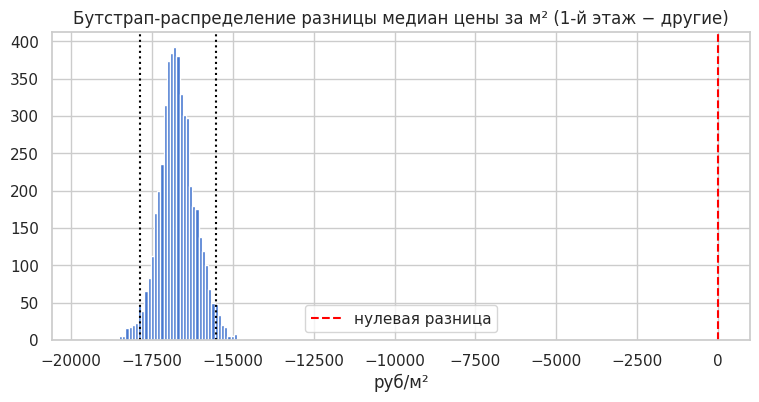

Разница медиан: -16772 руб/м², 95% ДИ: [-17861; -15534]


In [29]:
rng = np.random.default_rng(RANDOM_STATE)
f_vals, o_vals = first.to_numpy(), other.to_numpy()

boot_diff = np.array([
    np.median(rng.choice(f_vals, len(f_vals))) - np.median(rng.choice(o_vals, len(o_vals)))
    for _ in range(5000)
])
ci = np.percentile(boot_diff, [2.5, 97.5])

plt.figure(figsize=(9, 4))
plt.hist(boot_diff, bins=50, edgecolor='white')
plt.axvline(0, color='red', ls='--', label='нулевая разница')
plt.axvline(ci[0], color='black', ls=':'); plt.axvline(ci[1], color='black', ls=':')
plt.title('Бутстрап-распределение разницы медиан цены за м² (1-й этаж − другие)')
plt.xlabel('руб/м²'); plt.legend(); plt.show()
print(f'Разница медиан: {np.median(f_vals) - np.median(o_vals):.0f} руб/м², 95% ДИ: [{ci[0]:.0f}; {ci[1]:.0f}]')

**Вывод по бутстрапу:** 95%-й доверительный интервал разницы медиан целиком лежит ниже нуля и не содержит 0 → дисконт первого этажа подтверждается и на медианах. Эффект устойчив к скошенности распределения — вывод Гипотезы 2 надёжен.

## 5. Общие выводы

**О данных и предобработке:**
1. Датасет из 23.7 тыс. объявлений содержал типовые проблемы: пропуски трёх разных природ («не заполнено» = нет, «не посчитано» гео-сервисом, «объявление активно»), артефакты ввода (потолки 25 м), экстремальные выбросы элитного сегмента. Каждый тип обработан своим способом; потеряно менее 2% данных.

**Главные факты о рынке (EDA):**
2. Цена определяется прежде всего **размером** (r ≈ 0.77 с площадью) и **географией** (цена за м² падает с удалением от центра до ~10–12 км, дальше плато).
3. Удельная цена (руб/м²) **убывает** с числом комнат — маленькие лоты дороже за метр.
4. Медианный срок продажи — ~95 дней; быстрой можно считать продажу до 45 дней. В публикациях выражена сезонность (пики весной и осенью).

**Статистически подтверждено (α = 0.05):**
5. **СПб дороже области** на ~60% за м² (t-тест Уэлча, p ≪ 0.05).
6. **Первый этаж дешевле** на ~19% за м² (t-тест, p ≪ 0.05; подтверждено бутстрапом на медианах — 95% ДИ разницы не содержит 0).
7. **В СПб выше доля быстрых продаж** (~26% vs ~22%, z-тест долей, p ≪ 0.05) — город ликвиднее.
8. **Центр продаётся дольше окраин** (медианы 143 vs 92 дня, Манна-Уитни, p ≪ 0.05) — дорогой центральный фонд ищет покупателя дольше.

**Практическое применение:** локация, размер и категория этажа — обязательные признаки для модели оценки стоимости; при дизайне экспериментов на этом рынке необходимо стратифицировать по гео и учитывать сезонность окна теста.